# Heterogeneous per-zone TSO strategies with horizontal tie coordination

Each of the three fixed IEEE-39-bus TSO zones runs a **different** control
strategy this time (rather than divergent tracking *targets*, as in
`007_TIE_COORDINATION.py` / `008_TIE_MUTUAL_GRADIENT_DEMO.ipynb`):

- **Zone 1** -- classic voltage-schedule tracking, reference **1.02 p.u.**
- **Zone 2** (the DSO-rich zone, 5 HV sub-networks) -- "bounds-only": no
  tracking (`g_v = 0`), hard corridor `[1.00, 1.06]` p.u., and an active
  transmission-loss-minimisation objective (`g_loss`).
- **Zone 3** -- "pure reserve optimisation": no tracking (`g_v = 0`),
  reactive-reserve centering on synchronous generators and TS-DER
  (`g_res_sg`, `g_res_der`), default voltage bounds `[0.90, 1.10]`.

We compare `enable_tie_coordination=False` (OFF) against the two-loop
mutual-gradient coordinator (COORD) over a clean 360-minute (6 h) horizon,
and add a **windowed-trend** diagnostic (six 60-minute bins) to look for the
slow coordination degradation reported separately over long runs -- a known
open problem this notebook can *expose*, not fix.

**Per the repository's house style, stated up front:**

- **Assumptions:** IEEE-39-bus, fixed 3-zone partition
  (`network/zone_partition.py::fixed_zone_partition_ieee39`); cascaded OFO
  control (`control_scope="cascaded"`, the default); SimBench load/gen
  profile active (`use_profiles=True`); **no discrete contingency events**
  (clean scenario -- this deliberately overrides `make_cigre_config()`'s own
  baked-in gen-trip/load-step/line-trip schedule); the tie coordinator sees
  only cached controller-side sensitivities/gradients, never the plant.
- **Constraints:** power-flow feasibility every step; per-zone hard voltage
  corridor `[v_min_pu, v_max_pu]` (soft-slack enforced, weight
  `g_z_voltage`); `dV_ref` clipped to `+/- tie_dvref_max`; per-zone
  objective-worsening safeguard `tie_grad_eps`.
- **Actuators:** generator AVR setpoints, machine-transformer OLTCs,
  TS-connected DER (Q(V) w-shift), PCC Q setpoints to zone 2's five DSOs --
  the `make_cigre_config()` actuator set; zones 2/3's *DSO-layer* controllers
  (Q-tracking-to-TSO-setpoint, their own `dso_g_v`) are **unchanged** by this
  notebook -- only the TSO layer's per-zone objective is reconfigured.
- **Controlled outputs:** zone 1's EHV bus voltages (tracked to 1.02 p.u.);
  zone 2's EHV bus voltages (bounded only) and whole-network active losses;
  zone 3's synchronous-generator / TS-DER reactive-reserve centering;
  inter-zone tie-line reactive exchange and the negotiated boundary-voltage
  difference `dV_ref` under COORD.


## Coordination mechanism (unchanged from 007/008)

For a tie line `e=(i,j)` the coordinator negotiates the agreed boundary
voltage difference `dV_ref` from each zone's boundary-gradient marginal
`gamma = (grad J_zone . h_boundary) / ||h_boundary||^2`, where `grad J_zone`
is that zone's **full** objective gradient -- voltage tracking + reserve +
loss + effort, whichever terms are enabled:

```text
G     = kappa * gamma_i - (1 - kappa) * gamma_j
delta = -alpha * G - anchor * DB(dV_ref)
alpha   = tie_grad_step / (2 * g_v)      # g_v-agnostic step size
eps_obj = tie_grad_eps * g_v             # g_v-agnostic worsening cap
```

The coordinator treats `grad J_zone` as a black box -- it already correctly
incorporates whichever objective terms this notebook enables per zone, so
**no changes to `controller/tie_coordinator.py` are needed**. The important
caveat for *this* scenario is that `g_v` in the two formulas above is the
single **global** `MultiTSOConfig.g_v`, not a per-zone value -- see the
"Interpretation checklist" at the end for why that matters when two of the
three zones run `g_v = 0`.


In [1]:
from __future__ import annotations

import importlib.util
import pickle
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def find_project_root(start: "Path | None" = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "multi_tso_config.py").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not locate qOFO_GH project root from current working directory.")


PROJECT_ROOT = find_project_root()
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
OUT_DIR = PROJECT_ROOT / "results" / "010_tso_heterogeneous_strategies_demo"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Numeric module name -> import via file location (mirrors 007/008). This
# reuses 005's validated CIGRE base config rather than depending on 007's
# notebook-irrelevant globals (ZONE_VSET, L14, CLI argparse, ...).
spec = importlib.util.spec_from_file_location("cigre005", EXPERIMENTS_DIR / "005_CIGRE_MULTI.py")
cigre005 = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(cigre005)
# NOTE: 005's module-level code touches matplotlib itself, so the inline
# backend must be (re-)selected AFTER this import -- same cell ordering
# 008 uses around its own importlib load.

try:
    get_ipython().run_line_magic("matplotlib", "inline")  # type: ignore[name-defined]
except NameError:
    import matplotlib
    matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt

from experiments.helpers import ContingencyEvent
from experiments.runners import run_multi_tso_dso

_base = cigre005.make_cigre_config()
print(f"Project root: {PROJECT_ROOT}")
print(f"Output dir  : {OUT_DIR}")
print(f"make_cigre_config() base g_v={_base.g_v:g}, n_total_s={_base.n_total_s:g}s, "
      f"enable_tie_coordination={_base.enable_tie_coordination}, "
      f"{len(_base.contingencies)} built-in contingencies (this notebook clears them)")
del _base


Project root: Z:\Python_Projekte\qOFO_GH
Output dir  : Z:\Python_Projekte\qOFO_GH\results\010_tso_heterogeneous_strategies_demo
make_cigre_config() base g_v=1e+07, n_total_s=18000s, enable_tie_coordination=True, 6 built-in contingencies (this notebook clears them)


## Zone strategy spec

`ZONE_STRATEGIES` below is the "settable inside the script" surface: edit it
to change any zone's objective. `mode` is documentation only (not consumed
by the config); the actual behaviour comes entirely from `g_v` / `v_min_pu`
/ `v_max_pu` / `g_res_sg` / `g_res_der` / `g_loss`.

- `mode="track"`: nonzero `g_v`, a real tracking reference `v_ref`.
- `mode="bounds"`: `g_v=0.0`; the hard `[v_min_pu, v_max_pu]` corridor is the
  only voltage discipline; `v_ref=None` auto-fills to the corridor's
  midpoint and is used *only* as the tie-coordinator's `V_anchor` (it has
  zero gradient weight, so it is never actually tracked).
- `mode="reserve"`: `g_v=0.0`; `g_res_sg`/`g_res_der` drive the objective
  instead.


In [15]:
# ============================================================================
# ZONE_STRATEGIES -- edit this to change any zone's control strategy.
# Keys are the fixed 3-area IEEE-39 zone ids (network/zone_partition.py).
# ============================================================================
ZONE_STRATEGIES = {
    1: dict(
        mode="track",
        v_ref=1.02,             # deliberately LOW reference (not 1.05 as in 007/008)
        v_min_pu=0.90, v_max_pu=1.10,   # TSOControllerConfig defaults
        g_v=1.0e7,               # matches make_cigre_config()'s own g_v -- verified in
                                 # the sanity-check cell below. The tie coordinator's
                                 # step-size scale reads the GLOBAL g_v, not this
                                 # per-zone value -- see Risk 2 in the interpretation
                                 # checklist -- so keep these in sync.
        g_res_sg=0.0, g_res_der=0.0, g_loss=0.0,
        g_z_voltage=1e-12,       # repo-wide default (inert) -- g_v does the tracking here
    ),
    2: dict(
        mode="bounds",
        v_ref=None,              # auto -> band centre = 1.03; dummy tie-anchor only
        v_min_pu=1.00, v_max_pu=1.06,
        g_v=0.0,
        g_res_sg=0.0, g_res_der=0.0,
        g_loss=3.0e5,            # UNVALIDATED for this scenario -- see Verification
        # g_v=0 means NOTHING pulls this zone back inside [1.00,1.06] except the
        # slack penalty below -- at the repo-wide default (1e-12, inert) the loss
        # objective pushed V past 1.11 p.u. in the first run (Manu caught this).
        # Found via a smoke-scale (150-min) sweep of candidate weights: 1e-12/1e4/1e6
        # were all indistinguishable (~1.088 p.u. max); 1e8 first showed a real
        # effect (1.068); 1e9/3e9/1e10 progressively tightened it (1.061/1.060/1.060)
        # with near-identical zone-2 loss (~4.67 MW) -- i.e. diminishing returns past
        # ~1e9. 1e10 holds V_max within ~0.0001 p.u. of the 1.06 ceiling at 150 min
        # (6% of steps still marginally over -- it stays a SOFT bound, not hard).
        g_z_voltage=1e10,
    ),
    3: dict(
        mode="reserve",
        v_ref=None,              # auto -> band centre = 1.00 (default bounds)
        v_min_pu=0.90, v_max_pu=1.10,
        g_v=0.0,
        g_res_sg=1.0e4,          # UNVALIDATED -- no prior numeric precedent in this repo
        g_res_der=1.0e4,
        g_loss=0.0,
        g_z_voltage=1e-12,       # default bounds are wide [0.90,1.10] -- unlikely to bind
    ),
}
assert set(ZONE_STRATEGIES) == {1, 2, 3}, "expected exactly the fixed 3-area zones"

display(pd.DataFrame(ZONE_STRATEGIES).T)

# Tie-coordination tuning: copied as literals from experiments/007_TIE_COORDINATION.py
# TIE_KW (validated operating point, 2026-06-25). Deliberately overrides
# make_cigre_config()'s own baked-in tie tuning (tie_grad_step=0.1, tie_grad_eps=1e-4)
# so this notebook uses the same validated operating point as 007/008.
# tie_grad_eps is kept separate and adjustable -- 007's own sweep identified it as
# "the knob that governs the magnitude of coordinated exchange."
TIE_KW = dict(
    enable_tie_coordination=True,
    g_z_q_tie=0.0,
    tie_grad_step=0.5,
    tie_anchor=0.5,
    tie_deadband_v_pu=0.002,
    tie_dvref_max=0.08,
)
TIE_GRAD_EPS = 1e-3   # <-- easily-adjustable notebook variable

CONTINGENCY_SPECS: list = []   # clean scenario; add ContingencyEvent kwargs here later


def build_contingencies():
    return [ContingencyEvent(**spec) for spec in CONTINGENCY_SPECS]


HORIZON_MIN = 16*60
WINDOW_SIZE_MIN = 60
STEADY_MIN = 300          # last 2 windows (240-300, 300-360) for the scalar summary table
FORCE_RERUN = True       # set True to ignore any cached pickle and re-simulate


,mode,v_ref,v_min_pu,v_max_pu,g_v,g_res_sg,g_res_der,g_loss,g_z_voltage
1,track,1.02,0.9,1.1,10000000.0,0.0,0.0,0.0,0.0
2,bounds,None,1.0,1.06,0.0,0.0,0.0,300000.0,10000000000.0
3,reserve,None,0.9,1.1,0.0,10000.0,10000.0,0.0,0.0


,mode,v_ref,v_min_pu,v_max_pu,g_v,g_res_sg,g_res_der,g_loss,g_z_voltage
1,track,1.02,0.9,1.1,10000000.0,0.0,0.0,0.0,0.0
2,bounds,None,1.0,1.06,0.0,0.0,0.0,300000.0,10000000000.0
3,reserve,None,0.9,1.1,0.0,10000.0,10000.0,0.0,0.0


In [16]:
# Translate ZONE_STRATEGIES into the new per-zone MultiTSOConfig fields
# (configs/multi_tso_config.py: zone_v_setpoints_pu, zone_v_min_pu,
# zone_v_max_pu, zone_g_v, zone_tso_g_res_sg, zone_tso_g_res_der,
# zone_tso_g_loss). Mutates and returns cfg.
def apply_zone_strategies(cfg, strategies: dict):
    zone_v_setpoints, zone_v_min, zone_v_max = {}, {}, {}
    zone_g_v, zone_g_res_sg, zone_g_res_der, zone_g_loss, zone_g_z_voltage = {}, {}, {}, {}, {}

    for z, s in strategies.items():
        v_min = float(s["v_min_pu"]); v_max = float(s["v_max_pu"])
        v_ref = s.get("v_ref")
        zone_v_setpoints[z] = float(v_ref) if v_ref is not None else 0.5 * (v_min + v_max)
        zone_v_min[z] = v_min
        zone_v_max[z] = v_max
        zone_g_v[z] = float(s["g_v"])
        zone_g_res_sg[z] = float(s.get("g_res_sg", 0.0))
        zone_g_res_der[z] = float(s.get("g_res_der", 0.0))
        zone_g_loss[z] = float(s.get("g_loss", 0.0))
        zone_g_z_voltage[z] = float(s.get("g_z_voltage", 1e-12))

    cfg.zone_v_setpoints_pu = zone_v_setpoints
    cfg.zone_v_min_pu = zone_v_min
    cfg.zone_v_max_pu = zone_v_max
    cfg.zone_g_v = zone_g_v
    cfg.zone_tso_g_res_sg = zone_g_res_sg
    cfg.zone_tso_g_res_der = zone_g_res_der
    cfg.zone_tso_g_loss = zone_g_loss
    cfg.zone_g_z_voltage = zone_g_z_voltage

    # The runner's zone_v_rms_err_pu diagnostic is computed against the single
    # GLOBAL v_set = config.v_setpoint_pu for EVERY zone, not each zone's own
    # schedule. Aligning the global fallback with zone 1's reference makes
    # that pre-existing per-zone RMS-tracking-error field meaningful for zone
    # 1 -- the only zone with a real tracking target (see Risk 4 below).
    cfg.v_setpoint_pu = zone_v_setpoints[1]
    return cfg


In [17]:
def make_config(enable_tie_coordination: bool):
    cfg = cigre005.make_cigre_config()
    cfg.n_total_s = 60.0 * HORIZON_MIN
    cfg.verbose = 0
    cfg.run_stability_analysis = False
    cfg.contingencies = build_contingencies()   # overrides 005's own CIGRE contingency schedule
    apply_zone_strategies(cfg, ZONE_STRATEGIES)
    for f in ("live_plot_controller", "live_plot_cascade", "live_plot_system",
              "live_plot_tracking", "live_plot_tie_coordination"):
        setattr(cfg, f, False)

    if enable_tie_coordination:
        for k, v in TIE_KW.items():
            setattr(cfg, k, v)
        cfg.tie_grad_eps = float(TIE_GRAD_EPS)
    else:
        cfg.enable_tie_coordination = False   # make_cigre_config() defaults this True

    return cfg


In [18]:
# Fast, no-simulation check that ZONE_STRATEGIES actually produced different
# per-zone override dicts before burning any wall-clock time.
_cfg_off = make_config(False)
_cfg_coord = make_config(True)

assert _cfg_off.enable_tie_coordination is False
assert _cfg_coord.enable_tie_coordination is True
assert _cfg_off.zone_g_v == {1: 1.0e7, 2: 0.0, 3: 0.0}
assert _cfg_off.zone_v_min_pu == {1: 0.90, 2: 1.00, 3: 0.90}
assert _cfg_off.zone_v_max_pu == {1: 1.10, 2: 1.06, 3: 1.10}
assert _cfg_off.zone_tso_g_res_sg[3] == 1.0e4 and _cfg_off.zone_tso_g_res_sg[1] == 0.0
assert _cfg_off.zone_tso_g_loss[2] == 3.0e5 and _cfg_off.zone_tso_g_loss[1] == 0.0
assert _cfg_off.zone_g_z_voltage[2] == 1e10, (
    "zone 2's voltage-slack weight must be raised well above the repo default "
    "(1e-12) or its [1.00,1.06] corridor will not bind against g_loss -- see ZONE_STRATEGIES"
)
assert _cfg_off.v_setpoint_pu == ZONE_STRATEGIES[1]["v_ref"] == 1.02
assert ZONE_STRATEGIES[1]["g_v"] == _cfg_off.g_v, (
    "zone-1 g_v should match the base config's global g_v -- the tie "
    "coordinator's step-size scale reads cfg.g_v directly, not the per-zone "
    "dict (see Risk 2)."
)
print("Static config sanity checks passed.")
del _cfg_off, _cfg_coord


Static config sanity checks passed.
Static config sanity checks passed.


In [19]:
RUN_LOGS: dict = {}
MAX_RETRIES = 3


def case_key(enable_tie_coordination: bool) -> str:
    return "COORD" if enable_tie_coordination else "OFF"


def finite_mean(values) -> float:
    arr = np.asarray(list(values), dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(arr.mean()) if arr.size else float("nan")


def time_min(log) -> np.ndarray:
    return np.asarray([r.time_s / 60.0 for r in log], dtype=float)


def steady_window(log, cfg, steady_min):
    cutoff = cfg.n_total_s - steady_min * 60.0
    return [r for r in log if r.time_s >= cutoff]


def _pickle_path(key: str) -> Path:
    return OUT_DIR / f"log_{key}.pkl"


def run_case_resilient(enable_tie_coordination: bool, retries: int = MAX_RETRIES):
    # Cached (in-memory + on-disk), retried run of one OFF/COORD case.
    # A 360-min run is expensive; survive kernel restarts via the on-disk
    # pickle. The retry loop guards against the transient Z: network-share
    # drops noted in the daily logs -- one blip should not lose a 6-hour run.
    key = case_key(enable_tie_coordination)
    if key in RUN_LOGS:
        return RUN_LOGS[key]

    pkl = _pickle_path(key)
    if pkl.exists() and not FORCE_RERUN:
        with open(pkl, "rb") as f:
            log, cfg = pickle.load(f)
        print(f"Loaded cached {key} run: {pkl} ({len(log)} records)")
        RUN_LOGS[key] = (log, cfg)
        return RUN_LOGS[key]

    last_error = None
    for attempt in range(1, retries + 1):
        try:
            print(f"Running {key} (attempt {attempt}/{retries}) ...")
            cfg = make_config(enable_tie_coordination)
            t0 = time.perf_counter()
            log = run_multi_tso_dso(cfg)
            print(f"  {key}: {len(log)} records in {time.perf_counter() - t0:.1f} s")
            RUN_LOGS[key] = (log, cfg)
            with open(pkl, "wb") as f:
                pickle.dump((log, cfg), f)
            return RUN_LOGS[key]
        except Exception as exc:  # noqa: BLE001 - notebook diagnostics want the full failure
            last_error = exc
            print(f"  failed: {type(exc).__name__}: {exc}")
    raise RuntimeError(f"Case {key} failed after {retries} attempts") from last_error


In [20]:
# Smoke check: 2 TSO periods (mirrors 009_TSO_LOSS_TIE_SWEEP.py's own --smoke
# convention: n_total_s = 2 * tso_period_s). Deliberately bypasses
# run_case_resilient/RUN_LOGS so it never pollutes the real OFF/COORD cache.
# for _coord in (False, True):
#     _cfg_smoke = make_config(_coord)
#     _cfg_smoke.n_total_s = 2.0 * _cfg_smoke.tso_period_s
#     _cfg_smoke.verbose = 1     # triggers the runner's new "[zone z] g_v=... g_loss=..." print
#     _log_smoke = run_multi_tso_dso(_cfg_smoke)
#     print(f"smoke {'COORD' if _coord else 'OFF'}: {len(_log_smoke)} records, no exception\n")
# del _cfg_smoke, _log_smoke


Read the per-zone `[zone 1] ... [zone 2] ... [zone 3] ...` lines printed
above and confirm they match `ZONE_STRATEGIES`: zone 1 `g_v=1e+07`, zones 2/3
`g_v=0`; zone 2 `g_loss=3e+05`, others `0`; zone 3 `g_res_sg=1e+04`, others
`0`; bounds `[0.900,1.100]` / `[1.000,1.060]` / `[0.900,1.100]`. Also glance at
the COORD run for early `ReachabilityViolation`/solver-status warnings before
committing to the full 360-minute run below.


In [8]:
off_log, off_cfg = run_case_resilient(False)
coord_log, coord_cfg = run_case_resilient(True)
print(f"OFF:   {len(off_log)} records")
print(f"COORD: {len(coord_log)} records")


Running OFF (attempt 1/3) ...

  Zonal Generator Dispatch (per-zone residual-load balancing)
  Per-gen P cap: alpha * sn_mva   with alpha = 0.85
  Zone 1: 14 loads, 1 sgens, 3 gens  ->  P_gen range [70.0, 1300.7] MW, mean 412.1 MW
          spill_in : mean   20.7 MW, peak  185.1 MW   (zone exports to cover other zones)
          spill_out: mean    0.0 MW, peak    0.0 MW   (unmet residual absorbed by slack)
  Zone 2: 68 loads, 31 sgens, 1 gens  ->  P_gen range [0.0, 680.0] MW, mean 412.6 MW
          spill_in : mean    4.5 MW, peak   71.3 MW   (zone exports to cover other zones)
          spill_out: mean   15.3 MW, peak  131.6 MW   (unmet residual absorbed by slack)
  Zone 3: 31 loads, 12 sgens, 2 gens  ->  P_gen range [125.3, 680.0] MW, mean 448.8 MW
          spill_in : mean    0.0 MW, peak    0.1 MW   (zone exports to cover other zones)
          spill_out: mean    5.4 MW, peak   53.5 MW   (unmet residual absorbed by slack)
------------------------------------------------------------

C:\Users\Manuel Schwenke\AppData\Local\Temp\ipykernel_106780\2968595134.py:51: RuntimeWarning: enable_tie_coordination is True but g_z_q_tie <= 0; the Q_tie soft cap will be inert (free slack). Set g_z_q_tie > 0 to enforce the tie_q_band_mvar band.
  log = run_multi_tso_dso(cfg)



  Zonal Generator Dispatch (per-zone residual-load balancing)
  Per-gen P cap: alpha * sn_mva   with alpha = 0.85
  Zone 1: 14 loads, 1 sgens, 3 gens  ->  P_gen range [70.0, 1300.7] MW, mean 412.1 MW
          spill_in : mean   20.7 MW, peak  185.1 MW   (zone exports to cover other zones)
          spill_out: mean    0.0 MW, peak    0.0 MW   (unmet residual absorbed by slack)
  Zone 2: 68 loads, 31 sgens, 1 gens  ->  P_gen range [0.0, 680.0] MW, mean 412.6 MW
          spill_in : mean    4.5 MW, peak   71.3 MW   (zone exports to cover other zones)
          spill_out: mean   15.3 MW, peak  131.6 MW   (unmet residual absorbed by slack)
  Zone 3: 31 loads, 12 sgens, 2 gens  ->  P_gen range [125.3, 680.0] MW, mean 448.8 MW
          spill_in : mean    0.0 MW, peak    0.1 MW   (zone exports to cover other zones)
          spill_out: mean    5.4 MW, peak   53.5 MW   (unmet residual absorbed by slack)
------------------------------------------------------------------------
  System gen disp

C:\Users\Manuel Schwenke\AppData\Local\Temp\ipykernel_106780\2968595134.py:51: RuntimeWarning: enable_tie_coordination is True but g_z_q_tie <= 0; the Q_tie soft cap will be inert (free slack). Set g_z_q_tie > 0 to enforce the tie_q_band_mvar band.
  log = run_multi_tso_dso(cfg)



  Zonal Generator Dispatch (per-zone residual-load balancing)
  Per-gen P cap: alpha * sn_mva   with alpha = 0.85
  Zone 1: 14 loads, 1 sgens, 3 gens  ->  P_gen range [70.0, 1300.7] MW, mean 412.1 MW
          spill_in : mean   20.7 MW, peak  185.1 MW   (zone exports to cover other zones)
          spill_out: mean    0.0 MW, peak    0.0 MW   (unmet residual absorbed by slack)
  Zone 2: 68 loads, 31 sgens, 1 gens  ->  P_gen range [0.0, 680.0] MW, mean 412.6 MW
          spill_in : mean    4.5 MW, peak   71.3 MW   (zone exports to cover other zones)
          spill_out: mean   15.3 MW, peak  131.6 MW   (unmet residual absorbed by slack)
  Zone 3: 31 loads, 12 sgens, 2 gens  ->  P_gen range [125.3, 680.0] MW, mean 448.8 MW
          spill_in : mean    0.0 MW, peak    0.1 MW   (zone exports to cover other zones)
          spill_out: mean    5.4 MW, peak   53.5 MW   (unmet residual absorbed by slack)
------------------------------------------------------------------------
  System gen disp

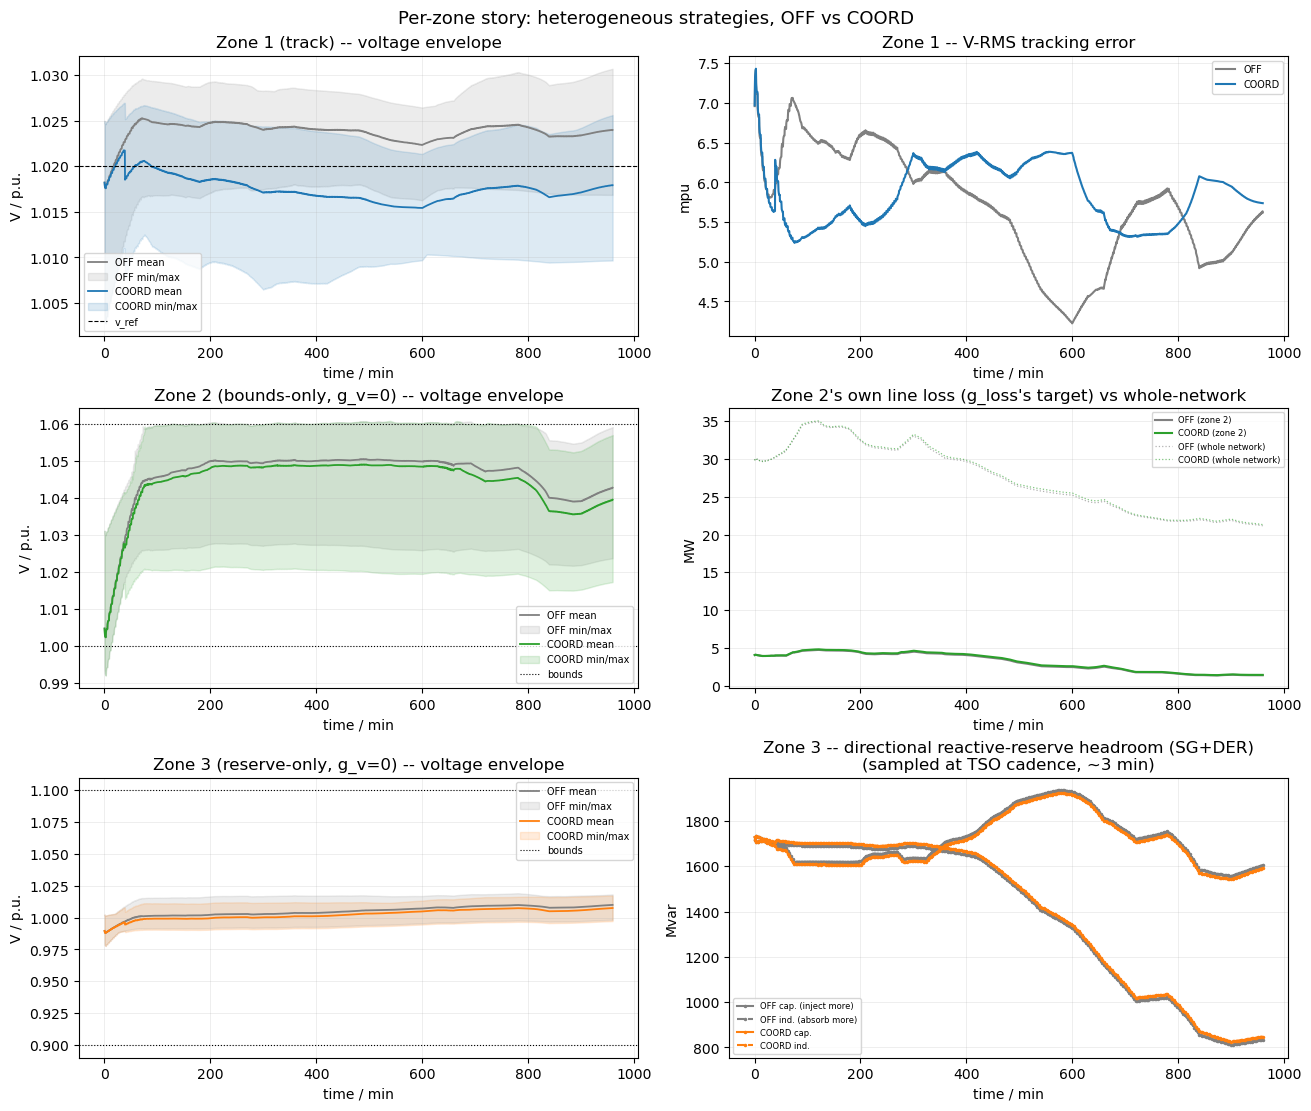

In [9]:
def _plot_envelope(ax, log, zone, color, label):
    t = time_min(log)
    vmin = np.array([r.zone_v_min.get(zone, np.nan) for r in log])
    vmax = np.array([r.zone_v_max.get(zone, np.nan) for r in log])
    vmean = np.array([r.zone_v_mean.get(zone, np.nan) for r in log])
    ax.plot(t, vmean, color=color, lw=1.3, label=f"{label} mean")
    ax.fill_between(t, vmin, vmax, color=color, alpha=0.15, label=f"{label} min/max")


def _valid_xy(log, getter):
    # Some per-zone diagnostics (e.g. reserve headroom) are only populated on
    # TSO ticks (every ~9th DSO-cadence record here), not every step -- the
    # rest are absent/NaN. Plotting the raw per-record array with no markers
    # renders NOTHING (no two consecutive finite points to connect a line
    # through). Filter to the actually-populated samples first.
    ts, vals = [], []
    for r in log:
        v = getter(r)
        if v is not None and np.isfinite(v):
            ts.append(r.time_s / 60.0)
            vals.append(v)
    return np.asarray(ts), np.asarray(vals)


fig, axs = plt.subplots(3, 2, figsize=(13, 11), constrained_layout=True)

# Row 1 -- Zone 1 (track, v_ref=1.02): the only zone with a real target.
ax = axs[0, 0]
_plot_envelope(ax, off_log, 1, "0.5", "OFF")
_plot_envelope(ax, coord_log, 1, "tab:blue", "COORD")
ax.axhline(ZONE_STRATEGIES[1]["v_ref"], color="k", ls="--", lw=0.8, label="v_ref")
ax.set_title("Zone 1 (track) -- voltage envelope"); ax.set_xlabel("time / min"); ax.set_ylabel("V / p.u.")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axs[0, 1]
ax.plot(time_min(off_log), [1e3 * r.zone_v_rms_err_pu.get(1, np.nan) for r in off_log], color="0.5", label="OFF")
ax.plot(time_min(coord_log), [1e3 * r.zone_v_rms_err_pu.get(1, np.nan) for r in coord_log], color="tab:blue", label="COORD")
ax.set_title("Zone 1 -- V-RMS tracking error"); ax.set_xlabel("time / min"); ax.set_ylabel("mpu")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# Row 2 -- Zone 2 (bounds-only, g_v=0, loss-focused). No tracking target, so
# its own driving signal is its OWN active-power line loss (zone_losses_mw,
# ground truth over exactly the lines g_loss targets -- current_line_indices).
# Whole-network total_losses_mw is shown faded/dashed alongside for context
# (it is NOT zone-2-only -- see the interpretation checklist).
ax = axs[1, 0]
_plot_envelope(ax, off_log, 2, "0.5", "OFF")
_plot_envelope(ax, coord_log, 2, "tab:green", "COORD")
ax.axhline(ZONE_STRATEGIES[2]["v_min_pu"], color="k", ls=":", lw=0.8, label="bounds")
ax.axhline(ZONE_STRATEGIES[2]["v_max_pu"], color="k", ls=":", lw=0.8)
ax.set_title("Zone 2 (bounds-only, g_v=0) -- voltage envelope"); ax.set_xlabel("time / min"); ax.set_ylabel("V / p.u.")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axs[1, 1]
ax.plot(time_min(off_log), [r.zone_losses_mw.get(2, np.nan) for r in off_log], color="0.5", label="OFF (zone 2)")
ax.plot(time_min(coord_log), [r.zone_losses_mw.get(2, np.nan) for r in coord_log], color="tab:green", label="COORD (zone 2)")
ax.plot(time_min(off_log), [r.total_losses_mw for r in off_log], color="0.5", ls=":", lw=0.9, alpha=0.6, label="OFF (whole network)")
ax.plot(time_min(coord_log), [r.total_losses_mw for r in coord_log], color="tab:green", ls=":", lw=0.9, alpha=0.6, label="COORD (whole network)")
ax.set_title("Zone 2's own line loss (g_loss's target) vs whole-network")
ax.set_xlabel("time / min"); ax.set_ylabel("MW"); ax.legend(fontsize=6); ax.grid(alpha=0.3)

# Row 3 -- Zone 3 (reserve-only, g_v=0). "Reactive power reserve" shown as the
# actual directional Mvar headroom (report_reserve_headroom: sum of remaining
# capacitive / inductive capability across zone 3's SG + TS-DER fleet) --
# a physically meaningful quantity, not the normalised [0,1] scarcity index.
ax = axs[2, 0]
_plot_envelope(ax, off_log, 3, "0.5", "OFF")
_plot_envelope(ax, coord_log, 3, "tab:orange", "COORD")
ax.axhline(ZONE_STRATEGIES[3]["v_min_pu"], color="k", ls=":", lw=0.8, label="bounds")
ax.axhline(ZONE_STRATEGIES[3]["v_max_pu"], color="k", ls=":", lw=0.8)
ax.set_title("Zone 3 (reserve-only, g_v=0) -- voltage envelope"); ax.set_xlabel("time / min"); ax.set_ylabel("V / p.u.")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axs[2, 1]
# zone_reserve_headroom_{cap,ind}_mvar are only populated on TSO ticks (see
# _valid_xy docstring) -- filter NaN gaps first or the line renders empty.
_t, _v = _valid_xy(off_log, lambda r: r.zone_reserve_headroom_cap_mvar.get(3))
ax.plot(_t, _v, color="0.5", ls="-", marker=".", ms=3, label="OFF cap. (inject more)")
_t, _v = _valid_xy(off_log, lambda r: r.zone_reserve_headroom_ind_mvar.get(3))
ax.plot(_t, _v, color="0.5", ls="--", marker=".", ms=3, label="OFF ind. (absorb more)")
_t, _v = _valid_xy(coord_log, lambda r: r.zone_reserve_headroom_cap_mvar.get(3))
ax.plot(_t, _v, color="tab:orange", ls="-", marker=".", ms=3, label="COORD cap.")
_t, _v = _valid_xy(coord_log, lambda r: r.zone_reserve_headroom_ind_mvar.get(3))
ax.plot(_t, _v, color="tab:orange", ls="--", marker=".", ms=3, label="COORD ind.")
ax.set_title("Zone 3 -- directional reactive-reserve headroom (SG+DER)\n(sampled at TSO cadence, ~3 min)")
ax.set_xlabel("time / min"); ax.set_ylabel("Mvar"); ax.legend(fontsize=6); ax.grid(alpha=0.3)

fig.suptitle("Per-zone story: heterogeneous strategies, OFF vs COORD", fontsize=13)
fig.savefig(OUT_DIR / "fig1_per_zone_story.png", dpi=150, bbox_inches="tight")
plt.show()


*Why this choice of metric per row:* `MultiTSOIterationRecord` has no
per-bus voltage **trace** array logged -- only `zone_v_min`/`zone_v_max`/
`zone_v_mean` (the zone-wide envelope) and `zone_v_rms_err_pu` (spatial RMS
error against the single global reference). The envelope + reference/bounds
overlay is the correct substitute for "voltage trace with band overlay" here.

Zone 2's and zone 3's right-hand panels use genuinely **per-zone** ground-truth
quantities (`zone_losses_mw`, `zone_reserve_headroom_cap_mvar` /
`_ind_mvar` -- both new/added for this notebook), not the whole-network
`total_losses_mw` or the abstract `zone_reserve_scarcity` index used in an
earlier version of this notebook -- see the interpretation checklist for why
that mattered.


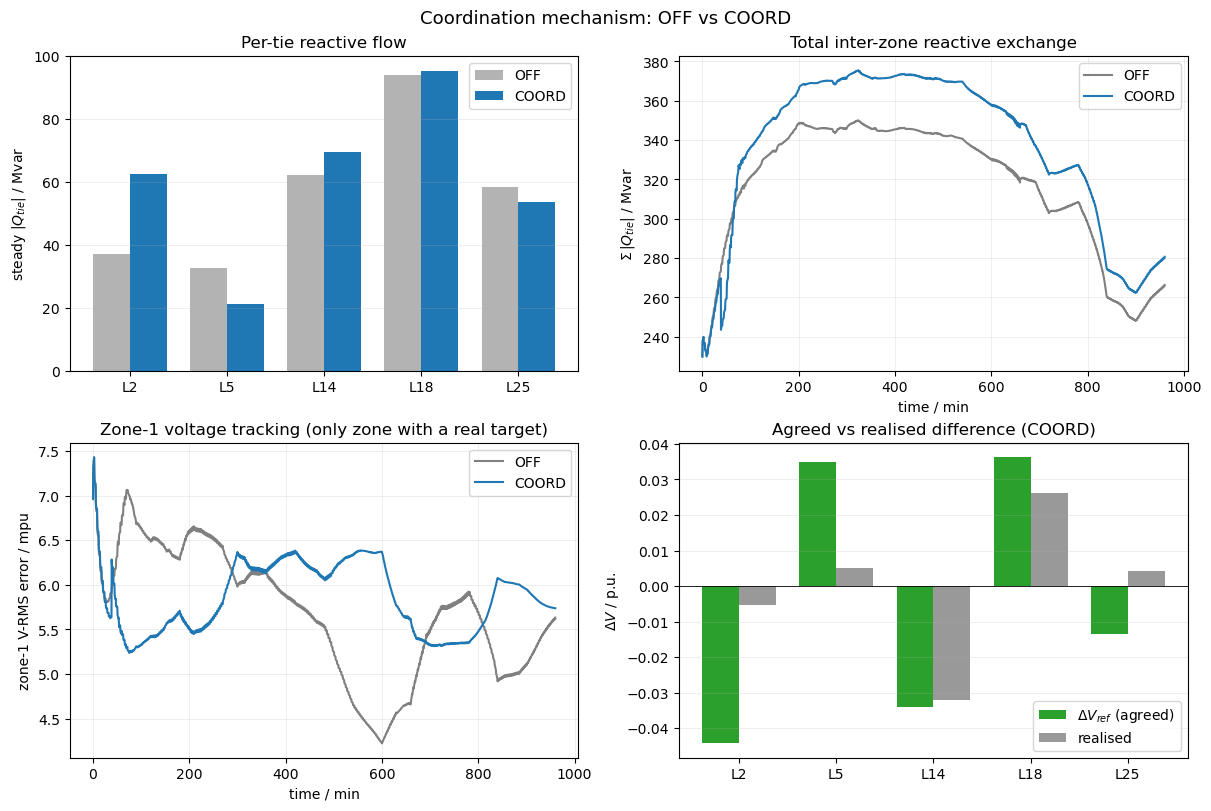

In [10]:
def steady_tie_metrics(log, cfg, steady_min):
    win = steady_window(log, cfg, steady_min)
    ties = sorted({li for r in win for li in r.tie_q_mvar})
    qabs = {li: finite_mean(abs(r.tie_q_mvar.get(li, np.nan)) for r in win) for li in ties}
    dvref = {li: finite_mean(r.tie_dvref.get(li, np.nan) for r in win) for li in ties}
    dvreal = {li: finite_mean(r.tie_dv_realized.get(li, np.nan) for r in win) for li in ties}
    return ties, qabs, dvref, dvreal


def sum_abs_tie_q_series(log):
    ties = sorted({li for r in log for li in r.tie_q_mvar})
    return np.array([sum(abs(r.tie_q_mvar.get(li, np.nan)) for li in ties) for r in log])


ties_off, q_off, _, _ = steady_tie_metrics(off_log, off_cfg, STEADY_MIN)
_, q_co, dvref, dvreal = steady_tie_metrics(coord_log, coord_cfg, STEADY_MIN)
ties = sorted(set(ties_off) | set(dvref))

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = np.arange(len(ties)); w = 0.38

ax = axs[0, 0]
ax.bar(x - w / 2, [q_off.get(li, np.nan) for li in ties], w, label="OFF", color="0.7")
ax.bar(x + w / 2, [q_co.get(li, np.nan) for li in ties], w, label="COORD", color="tab:blue")
ax.set_xticks(x); ax.set_xticklabels([f"L{li}" for li in ties])
ax.set_ylabel(r"steady $|Q_{tie}|$ / Mvar"); ax.set_title("Per-tie reactive flow")
ax.legend(); ax.grid(alpha=0.3, axis="y")

ax = axs[0, 1]
ax.plot(time_min(off_log), sum_abs_tie_q_series(off_log), color="0.5", label="OFF")
ax.plot(time_min(coord_log), sum_abs_tie_q_series(coord_log), color="tab:blue", label="COORD")
ax.set_xlabel("time / min"); ax.set_ylabel(r"$\Sigma\,|Q_{tie}|$ / Mvar")
ax.set_title("Total inter-zone reactive exchange"); ax.legend(); ax.grid(alpha=0.3)

# Zone-1-only V-RMS (NOT mean-over-all-zones as in 007): zones 2/3 run g_v=0,
# so their zone_v_rms_err_pu is deviation from zone 1's global v_set with no
# corresponding objective term -- not a meaningful "tracking error" (Risk 4).
ax = axs[1, 0]
ax.plot(time_min(off_log), [1e3 * r.zone_v_rms_err_pu.get(1, np.nan) for r in off_log], color="0.5", label="OFF")
ax.plot(time_min(coord_log), [1e3 * r.zone_v_rms_err_pu.get(1, np.nan) for r in coord_log], color="tab:blue", label="COORD")
ax.set_xlabel("time / min"); ax.set_ylabel("zone-1 V-RMS error / mpu")
ax.set_title("Zone-1 voltage tracking (only zone with a real target)")
ax.legend(); ax.grid(alpha=0.3)

ax = axs[1, 1]
ax.bar(x - w / 2, [dvref.get(li, np.nan) for li in ties], w, label=r"$\Delta V_{ref}$ (agreed)", color="tab:green")
ax.bar(x + w / 2, [dvreal.get(li, np.nan) for li in ties], w, label="realised", color="0.6")
ax.axhline(0.0, color="k", lw=0.6)
ax.set_xticks(x); ax.set_xticklabels([f"L{li}" for li in ties])
ax.set_ylabel(r"$\Delta V$ / p.u."); ax.set_title("Agreed vs realised difference (COORD)")
ax.legend(); ax.grid(alpha=0.3, axis="y")

fig.suptitle("Coordination mechanism: OFF vs COORD", fontsize=13)
fig.savefig(OUT_DIR / "fig2_coordination_mechanism.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
WINDOW_EDGES_MIN = np.arange(0, HORIZON_MIN + 1, WINDOW_SIZE_MIN)   # [0,60,...,360] -> 6 windows
WINDOW_LABELS = [f"{int(a)}-{int(b)}" for a, b in zip(WINDOW_EDGES_MIN[:-1], WINDOW_EDGES_MIN[1:])]


def windowed_metrics(log, edges_min):
    # Per-window mean of the headline metrics, plus a reference system-load
    # trace (total_load_p_mw) so a rising/falling panel can be checked against
    # the SimBench profile's own diurnal ramp before being read as coordination
    # drift (see the windowed-trend risk in the interpretation checklist).
    # zone_loss_z2_mw / reserve_headroom_min_z3_mvar are genuinely per-zone
    # ground truth (not the whole-network / abstract-index substitutes used
    # in an earlier version of this notebook).
    t_min = time_min(log)
    n_win = len(edges_min) - 1
    keys = ("v_rms_z1_mpu", "sum_abs_tie_q_mvar", "zone_loss_z2_mw",
            "reserve_headroom_min_z3_mvar", "total_load_p_mw")
    out = {k: np.full(n_win, np.nan) for k in keys}
    for i in range(n_win):
        lo, hi = edges_min[i], edges_min[i + 1]
        is_last = (i == n_win - 1)
        mask = (t_min >= lo) & ((t_min <= hi) if is_last else (t_min < hi))
        win = [r for r, m in zip(log, mask) if m]
        if not win:
            continue
        out["v_rms_z1_mpu"][i] = 1e3 * finite_mean(r.zone_v_rms_err_pu.get(1, np.nan) for r in win)
        win_ties = sorted({li for r in win for li in r.tie_q_mvar})
        out["sum_abs_tie_q_mvar"][i] = (
            sum(finite_mean(abs(r.tie_q_mvar.get(li, np.nan)) for r in win) for li in win_ties)
            if win_ties else np.nan
        )
        out["zone_loss_z2_mw"][i] = finite_mean(r.zone_losses_mw.get(2, np.nan) for r in win)
        out["reserve_headroom_min_z3_mvar"][i] = finite_mean(
            np.fmin(r.zone_reserve_headroom_cap_mvar.get(3, np.nan), r.zone_reserve_headroom_ind_mvar.get(3, np.nan))
            for r in win
        )
        out["total_load_p_mw"][i] = finite_mean(r.total_load_p_mw for r in win)
    return out


wm_off = windowed_metrics(off_log, WINDOW_EDGES_MIN)
wm_coord = windowed_metrics(coord_log, WINDOW_EDGES_MIN)


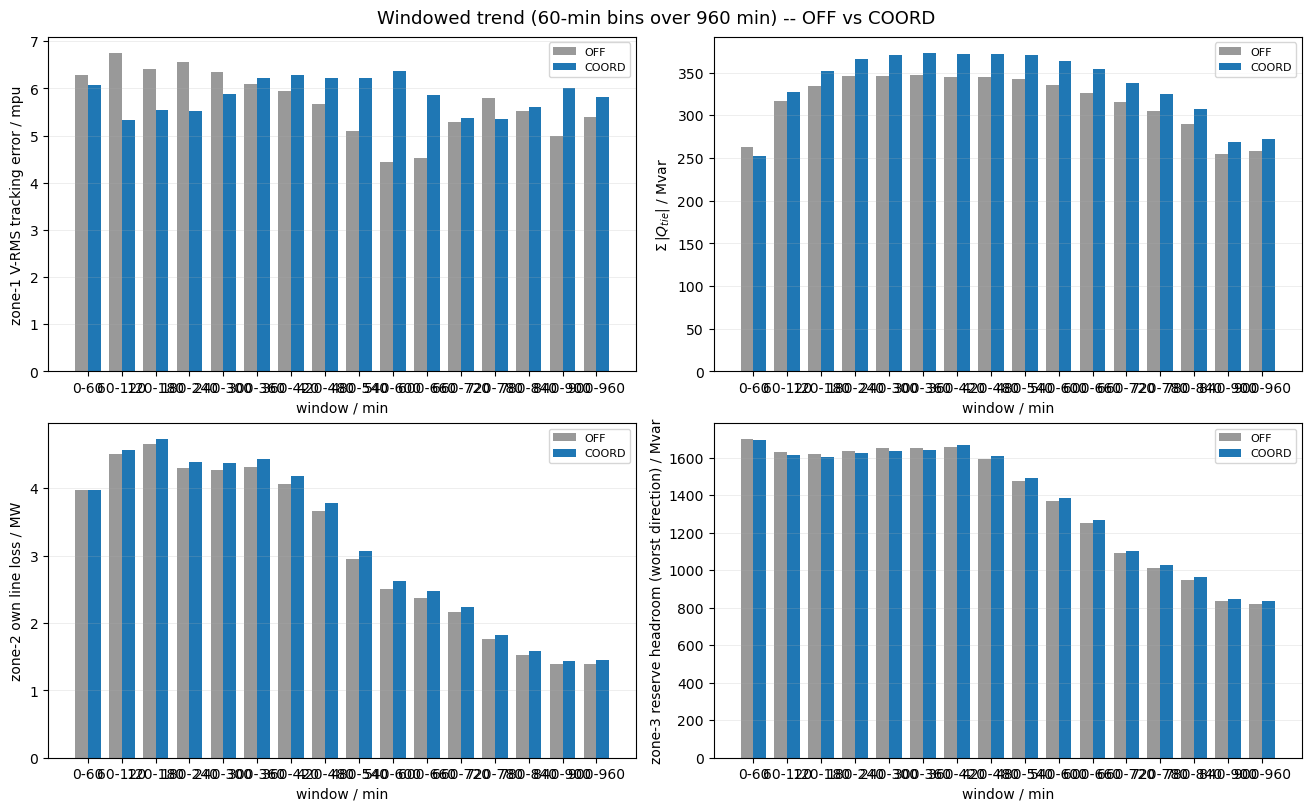

Reference: mean system load per window (MW, OFF run) -- [4749.9, 4906.4, 4918.8, 4745.7, 4688.7, 4694.8, 4631.0, 4731.5, 4820.5, 4836.5, 4894.1, 4912.3, 4713.4, 4561.5, 4435.2, 4315.4]
If a metric rises/falls monotonically across windows while load stays flat, that is
evidence of a genuine drift; if it tracks the load shape, it is profile-driven (see checklist).


In [12]:
fig, axs = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
panels = [
    ("v_rms_z1_mpu", "zone-1 V-RMS tracking error / mpu", axs[0, 0]),
    ("sum_abs_tie_q_mvar", r"$\Sigma\,|Q_{tie}|$ / Mvar", axs[0, 1]),
    ("zone_loss_z2_mw", "zone-2 own line loss / MW", axs[1, 0]),
    ("reserve_headroom_min_z3_mvar", "zone-3 reserve headroom (worst direction) / Mvar", axs[1, 1]),
]
x = np.arange(len(WINDOW_LABELS)); w = 0.38
for key, ylabel, ax in panels:
    ax.bar(x - w / 2, wm_off[key], w, label="OFF", color="0.6")
    ax.bar(x + w / 2, wm_coord[key], w, label="COORD", color="tab:blue")
    ax.set_xticks(x); ax.set_xticklabels(WINDOW_LABELS)
    ax.set_xlabel("window / min"); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis="y"); ax.legend(fontsize=8)

fig.suptitle(f"Windowed trend ({WINDOW_SIZE_MIN}-min bins over {HORIZON_MIN} min) -- OFF vs COORD", fontsize=13)
fig.savefig(OUT_DIR / "fig3_windowed_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print("Reference: mean system load per window (MW, OFF run) --", np.round(wm_off["total_load_p_mw"], 1).tolist())
print("If a metric rises/falls monotonically across windows while load stays flat, that is")
print("evidence of a genuine drift; if it tracks the load shape, it is profile-driven (see checklist).")


## Realized per-zone MIQP objective

`zone_tso_objective[z]` is each zone's **full solved MIQP objective value**
(`MIQPResult.objective_value`) -- not just the "story" term (`g_v`'s tracking
cost / `g_loss`'s loss cost / `g_res_sg`+`g_res_der`'s reserve cost) in
isolation. It also includes that zone's `g_w` move-penalty regularization and
any active `g_z` slack costs, so it is the right number for "how expensive is
this zone's whole solve," not a clean isolated readout of just the
strategy-specific term.

**This value is signed and is usually negative** -- confirmed directly from
this run's data (zones 1 and 3 are negative at every single sample; zone 2 is
negative most of the time but occasionally positive). This is expected for a
linearised, projected-gradient OFO MIQP: the reported objective is the local
QP model's value at the chosen step, i.e. roughly "predicted change from
taking this step," not an absolute cost level -- negative means the step is
locally improving. Because a log scale cannot represent signed values, the
figure below plots **|objective value|** (magnitude only, sign discarded) so
the very different weight scales (`g_v=1e7` vs `g_loss=3e5` vs
`g_res_sg=g_res_der=1e4`) can share one log-scale axis without one flattening
the others. It is only populated at TSO cadence (~3 min, same sampling issue
as the reserve-headroom figure above) -- filtered accordingly below.


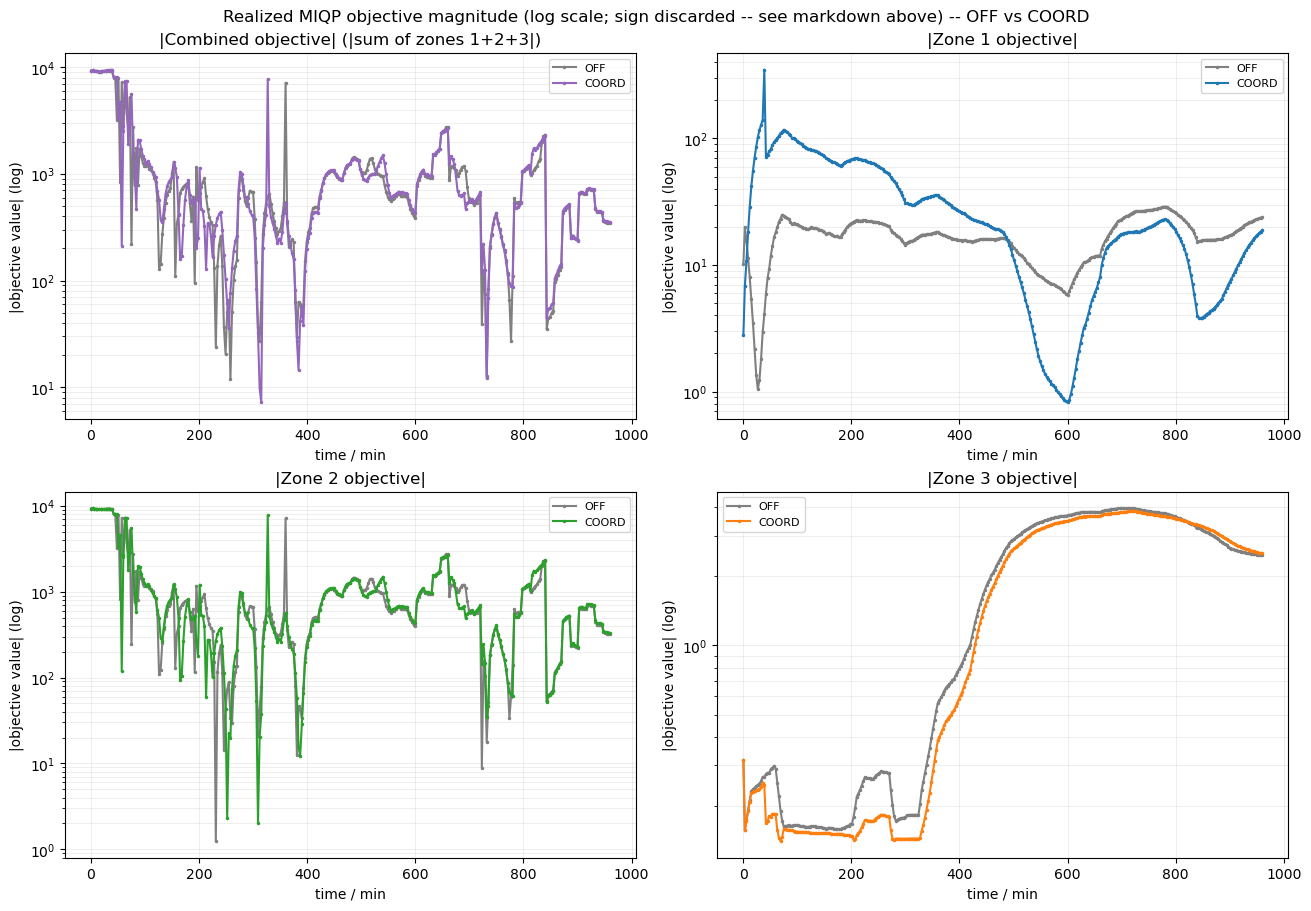

Fraction of TSO ticks with NEGATIVE objective value (OFF run): {'zone1': np.float64(1.0), 'zone2': np.float64(0.396), 'zone3': np.float64(1.0)}


In [13]:
def _valid_xy_abs_sum(log, getters):
    # Like _valid_xy, but sums several getters (magnitude of the sum, since
    # zone_tso_objective is signed -- see markdown above) and only keeps
    # records where ALL getters are simultaneously valid (the combined
    # objective needs all 3 zones' values from the same TSO tick).
    ts, vals = [], []
    for r in log:
        vs = [g(r) for g in getters]
        if all(v is not None and np.isfinite(v) for v in vs):
            ts.append(r.time_s / 60.0)
            vals.append(abs(sum(vs)))
    return np.asarray(ts), np.asarray(vals)


fig, axs = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

getters = [(lambda r, z=z: r.zone_tso_objective.get(z)) for z in (1, 2, 3)]
ax = axs[0, 0]
_t, _v = _valid_xy_abs_sum(off_log, getters)
ax.plot(_t, _v, color="0.5", marker=".", ms=3, label="OFF")
_t, _v = _valid_xy_abs_sum(coord_log, getters)
ax.plot(_t, _v, color="tab:purple", marker=".", ms=3, label="COORD")
ax.set_yscale("log")
ax.set_title("|Combined objective| (|sum of zones 1+2+3|)")
ax.set_xlabel("time / min"); ax.set_ylabel("|objective value| (log)")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

zone_axes = {1: axs[0, 1], 2: axs[1, 0], 3: axs[1, 1]}
zone_colors = {1: "tab:blue", 2: "tab:green", 3: "tab:orange"}
for z, ax in zone_axes.items():
    _t, _v = _valid_xy(off_log, lambda r, z=z: r.zone_tso_objective.get(z))
    ax.plot(_t, np.abs(_v), color="0.5", marker=".", ms=3, label="OFF")
    _t, _v = _valid_xy(coord_log, lambda r, z=z: r.zone_tso_objective.get(z))
    ax.plot(_t, np.abs(_v), color=zone_colors[z], marker=".", ms=3, label="COORD")
    ax.set_yscale("log")
    ax.set_title(f"|Zone {z} objective|")
    ax.set_xlabel("time / min"); ax.set_ylabel("|objective value| (log)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

fig.suptitle("Realized MIQP objective magnitude (log scale; sign discarded -- see markdown above) -- OFF vs COORD", fontsize=12)
fig.savefig(OUT_DIR / "fig4_zone_objectives.png", dpi=150, bbox_inches="tight")
plt.show()

_off_neg_frac = {z: np.mean(np.array([v for v in (r.zone_tso_objective.get(z) for r in off_log) if v is not None]) < 0) for z in (1, 2, 3)}
print("Fraction of TSO ticks with NEGATIVE objective value (OFF run):", {f"zone{z}": round(f, 3) for z, f in _off_neg_frac.items()})


In [14]:
def summarize(log, cfg, label, steady_min):
    win = steady_window(log, cfg, steady_min)
    _, qabs, _, _ = steady_tie_metrics(log, cfg, steady_min)
    return {
        "case": label,
        "v_rms_z1_mpu": 1e3 * finite_mean(r.zone_v_rms_err_pu.get(1, np.nan) for r in win),
        "sum_abs_tie_q_mvar": sum(qabs.values()) if qabs else np.nan,
        "zone_loss_z2_mw": finite_mean(r.zone_losses_mw.get(2, np.nan) for r in win),
        "total_losses_mw": finite_mean(r.total_losses_mw for r in win),
        "reserve_headroom_cap_z3_mvar": finite_mean(r.zone_reserve_headroom_cap_mvar.get(3, np.nan) for r in win),
        "reserve_headroom_ind_z3_mvar": finite_mean(r.zone_reserve_headroom_ind_mvar.get(3, np.nan) for r in win),
        "v_min_z2_pu": min((r.zone_v_min.get(2, np.nan) for r in win), default=np.nan),
        "v_max_z2_pu": max((r.zone_v_max.get(2, np.nan) for r in win), default=np.nan),
        "n_records": len(log),
        "n_steady_records": len(win),
    }


summary_df = pd.DataFrame([
    summarize(off_log, off_cfg, "OFF", STEADY_MIN),
    summarize(coord_log, coord_cfg, "COORD", STEADY_MIN),
]).set_index("case")
summary_df.loc["Delta(COORD-OFF)"] = summary_df.loc["COORD"] - summary_df.loc["OFF"]

display(summary_df.style.format({
    "v_rms_z1_mpu": "{:.3f}", "sum_abs_tie_q_mvar": "{:.1f}",
    "zone_loss_z2_mw": "{:.3f}", "total_losses_mw": "{:.3f}",
    "reserve_headroom_cap_z3_mvar": "{:.2f}", "reserve_headroom_ind_z3_mvar": "{:.2f}",
    "v_min_z2_pu": "{:.4f}", "v_max_z2_pu": "{:.4f}",
}))
summary_df.to_csv(OUT_DIR / "summary.csv")
print(f"Saved: {OUT_DIR / 'summary.csv'}")


,v_rms_z1_mpu,sum_abs_tie_q_mvar,zone_loss_z2_mw,total_losses_mw,reserve_headroom_cap_z3_mvar,reserve_headroom_ind_z3_mvar,v_min_z2_pu,v_max_z2_pu,n_records,n_steady_records
case,,,,,,,,,,
OFF,5.400,284.7,1.647,22.110,1668.41,940.84,1.0217,1.0606,2880.000000,901.000000
COORD,5.633,302.3,1.703,22.258,1654.29,954.95,1.0150,1.0607,2880.000000,901.000000
Delta(COORD-OFF),0.233,17.6,0.055,0.148,-14.12,14.12,-0.0067,0.0001,0.000000,0.000000


Saved: Z:\Python_Projekte\qOFO_GH\results\010_tso_heterogeneous_strategies_demo\summary.csv


## Interpretation checklist

When discussing this run, state assumptions, constraints, actuators, and
controlled outputs (per this repo's house style):

- **Assumptions:** IEEE-39, fixed 3-zone partition; cascaded OFO; clean
  360-min SimBench-profile-driven scenario (no discrete contingencies, but
  the background load still ramps over the day -- check the reference load
  trace in Figure 3's printout before calling any windowed trend a
  "degradation").
- **Constraints:** per-zone hard voltage corridor (soft-slack enforced,
  `g_z_voltage`), `dV_ref` clipped to `+/- tie_dvref_max`, per-zone
  objective-worsening safeguard `tie_grad_eps`.
- **Actuators:** generator AVR, machine-transformer OLTCs, TS-DER Q(V),
  PCC Q setpoints to zone 2's 5 DSOs; DSO-layer objectives are unchanged.
- **Controlled outputs:** zone 1 EHV voltage tracking (1.02 p.u.); zone 2
  EHV voltage corridor + whole-network active loss; zone 3 reactive-reserve
  centering; inter-zone tie flow and negotiated `dV_ref`.
- **Result pattern to report:** does COORD reduce zone-1 V-RMS error and/or
  `Sigma|Q_tie|` vs OFF; does zone 2's OWN line loss (`zone_losses_mw[2]`,
  not the whole-network total) respond to `g_loss`; does zone 3's reactive
  headroom (`zone_reserve_headroom_cap_mvar`/`_ind_mvar[3]`, in Mvar) improve
  under `g_res_sg`/`g_res_der`.
- **Windowed-trend question (the reason this notebook exists):** does any
  panel in Figure 3 show a monotonic rise/fall across the six windows for
  COORD that is *not* present for OFF and *not* explained by the reference
  load trend? That is the signature of the separately-reported "coordination
  degrades over long runs" issue. This notebook is diagnostic only -- do not
  attempt to fix the mechanism here if found.

**Open risks to keep in mind (not established results):**

1. `g_loss=3e5` (zone 2) and `g_res_sg=g_res_der=1e4` (zone 3) are
   unvalidated starting guesses -- there is no prior numeric precedent for
   `g_res_sg`/`g_res_der` anywhere in this repo. If Figure 1's loss/reserve
   panels look flat, rerun with that zone's weight set to `0.0` as a
   throwaway ablation before concluding the weight is well-tuned.
2. The tie coordinator's step size (`grad_alpha`/`grad_eps`) is derived from
   the single *global* `g_v` (kept pinned to zone 1's value, asserted
   above), not any per-zone value -- so it is well-calibrated for zone 1's
   side of a tie but not necessarily for zone 2/3's side, whose curvature
   comes from `g_loss` / `g_res_sg` / `g_res_der` instead. `TIE_GRAD_EPS` is
   the first lever to shrink if Figure 2/3 show oscillation or saturation.
3. L14 (zone 1 <-> zone 2, at the slack bus) is expected to remain
   structurally pinned as in 007/008 (a topological property of the slack
   bus), but the pull from each side now differs in both magnitude and kind
   (zone 1's target dropped to 1.02; zone 2's pull is loss-driven, not
   tracking-driven).
4. `zone_v_rms_err_pu` is computed against one global reference
   (`cfg.v_setpoint_pu`, fixed to zone 1's 1.02 above) for every zone, so
   zones 2/3's own values are not a meaningful "tracking error" -- this is
   exactly why Figures 1/2 only plot it for zone 1.
5. `zone_losses_mw[2]` only covers zone 2's own EHV lines
   (`current_line_indices`, exactly what `g_loss` targets) -- it does NOT
   include zone 2's PCC/OLTC transformers or its DSO sub-networks' own HV
   lines, so it is a lower bound on "everything g_loss could plausibly
   affect," not zone 2's total footprint loss.
6. `zone_2["g_z_voltage"]=1e10` was picked from a smoke-scale (150-min)
   sweep that held V_max within ~0.0001 p.u. of the 1.06 ceiling with only a
   ~6% marginal-overshoot fraction and near-zero further loss-objective
   cost past that point (see ZONE_STRATEGIES comment) -- it is a soft bound
   by design, so re-check Figure 1's zone-2 envelope on every rerun rather
   than assuming it always holds this tightly (e.g. if `g_loss` is later
   increased, this weight would likely need to increase too).

**Open questions to keep separate from established results:** whether this
scenario's tuning generalises to other zone/strategy assignments; whether
the windowed-trend pattern seen here (if any) matches the degradation
reported for the divergent-voltage-reference scenario, which would suggest
a shared root cause rather than something specific to either scenario.
